# Tache 2 - Workflow B : Guided Search Agentique
## Projet Data Quality - Pattern Functional Dependencies

**Architecture :**
```
Algo Classique (Tache 1 - camarade)
  pattern_extractor -> candidate_generator -> pfd_verifier -> rule_generalizer

Workflow B (Tache 2 - notre code)
  LLM propose candidats -> pfd_verifier valide -> PFDs decouvertes
```

## Etape 1 - Installation

In [1]:
!pip install google-genai groq pandas matplotlib -q
print('OK - librairies installees')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.5 MB/s eta 0:00:00
OK - librairies installees


## Etape 2 - Cles API

charagement des clés API

In [2]:
from google.colab import userdata
GEMINI_KEY = userdata.get('GEMINI_API_KEY')
GROQ_KEY   = userdata.get('GROQ_API_KEY')
print('OK - cles chargees')

OK - cles chargees


## Etape 3 - Code du camarade (Tache 1)

On integre ici les 4 modules de la Tache 1 :
- `pfd_verifier` : valide une PFD (support + confiance)
- `pattern_extractor` : extrait les patterns des colonnes
- `candidate_generator` : genere les candidats
- `rule_generalizer` : generalise et elague les regles
- `pfd_discovery` : orchestre le pipeline complet

In [5]:
# ================================================================
#  pfd_verifier.py -tache 1
# ================================================================
import re
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from itertools import groupby

def _match_pattern(series, pattern, match_type):
    if match_type == 'exact':
        return series == pattern
    not_null    = series.notna()
    s           = series.astype(str)
    pattern_str = str(pattern)
    if match_type == 'startswith':
        return not_null & s.str.startswith(pattern_str)
    elif match_type == 'contains':
        return not_null & s.str.contains(pattern_str, regex=False, na=False)
    elif match_type == 'regex':
        try:
            re.compile(pattern_str)
        except re.error as e:
            raise ValueError(f'Pattern regex invalide : {e}')
        return not_null & s.str.contains(pattern_str, regex=True, na=False)
    else:
        raise ValueError(f"match_type inconnu : '{match_type}'")

def verifier_pfd(df, col_X, pattern_X, col_Y, pattern_Y,
                 epsilon=0.05, match_type='exact',
                 match_type_X=None, match_type_Y=None):
    mt_X = match_type_X if match_type_X is not None else match_type
    mt_Y = match_type_Y if match_type_Y is not None else match_type
    mask_X = _match_pattern(df[col_X], pattern_X, mt_X)
    n_matching_X = int(mask_X.sum())
    if n_matching_X == 0:
        return {'confidence': 0.0, 'is_valid': False, 'n_matching_X': 0,
                'n_valid': 0, 'n_violations': 0, 'epsilon': epsilon,
                'examples_violations': []}
    df_X = df[mask_X].copy()
    mask_Y = _match_pattern(df_X[col_Y], pattern_Y, mt_Y)
    n_valid = int(mask_Y.sum())
    n_violations = n_matching_X - n_valid
    confidence = n_valid / n_matching_X
    is_valid = confidence >= (1.0 - epsilon)
    examples = df_X[~mask_Y].head(3).to_dict('records')
    return {'confidence': round(confidence, 6), 'is_valid': is_valid,
            'n_matching_X': n_matching_X, 'n_valid': n_valid,
            'n_violations': n_violations, 'epsilon': epsilon,
            'examples_violations': examples}

print('OK - pfd_verifier')

OK - pfd_verifier


In [4]:
# ================================================================
#  pattern_extractor.py  -  Tache 1
# ================================================================

def extract_prefixes(value, k_max=5):
    if not isinstance(value, str) or not value:
        return []
    return [value[:k] for k in range(1, min(k_max + 1, len(value) + 1))]

def extract_tokens(value):
    if not isinstance(value, str) or not value:
        return []
    tokens = re.split(r'[\s\-_/,.;:]+', value.strip())
    return [t for t in tokens if t]

def prefix_patterns(series, k_max=5, min_support=5):
    buckets = defaultdict(list)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        s = str(val)
        for k in range(1, min(k_max + 1, len(s) + 1)):
            buckets[s[:k]].append(idx)
    return {p: idxs for p, idxs in buckets.items() if len(idxs) >= min_support}

def token_patterns(series, min_support=5):
    buckets = defaultdict(list)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        tokens = extract_tokens(str(val))
        if tokens:
            buckets[tokens[0]].append(idx)
    return {t: idxs for t, idxs in buckets.items() if len(idxs) >= min_support}

def extract_all_patterns(series, k_max=5, min_support=5):
    result = {}
    pref = prefix_patterns(series, k_max=k_max, min_support=min_support)
    if pref:
        result['startswith'] = pref
    toks = token_patterns(series, min_support=min_support)
    if toks:
        result['first_token'] = toks
    return result

print('OK - pattern_extractor')

OK - pattern_extractor


In [6]:
# ================================================================
#  candidate_generator.py  -  Tache 1
# ================================================================

def _most_common_value(series):
    non_null = series.dropna()
    if non_null.empty:
        return None, 0, 0
    counts = Counter(non_null.astype(str) if non_null.dtype.kind == 'f' else non_null)
    top_val, top_count = counts.most_common(1)[0]
    if non_null.dtype.kind in ('f', 'i'):
        try:
            top_val = type(non_null.iloc[0])(top_val)
        except (ValueError, TypeError):
            pass
    return top_val, top_count, len(non_null)

def generate_candidates(df, col_X, pattern_map, match_type, target_cols, min_support=5):
    effective_mt_X = 'startswith' if match_type == 'first_token' else match_type
    candidates = []
    for pattern, indices in pattern_map.items():
        if len(indices) < min_support:
            continue
        df_group = df.loc[indices]
        for col_Y in target_cols:
            if col_Y == col_X:
                continue
            top_val, top_count, total = _most_common_value(df_group[col_Y])
            if top_val is None or total == 0:
                continue
            raw_conf = top_count / total
            candidates.append({
                'col_X': col_X, 'pattern_X': pattern,
                'match_type_X': effective_mt_X,
                'col_Y': col_Y, 'pattern_Y': top_val,
                'match_type_Y': 'exact',
                'support': len(indices),
                'raw_confidence': round(raw_conf, 6),
            })
    return candidates

def generate_all_candidates(df, pattern_maps, target_cols=None, min_support=5):
    if target_cols is None:
        target_cols = list(df.columns)
    all_candidates = []
    for col_X, type_map in pattern_maps.items():
        for match_type, pmap in type_map.items():
            batch = generate_candidates(df, col_X, pmap, match_type, target_cols, min_support)
            all_candidates.extend(batch)
    seen = set()
    unique = []
    for c in all_candidates:
        key = (c['col_X'], str(c['pattern_X']), c['match_type_X'],
               c['col_Y'], str(c['pattern_Y']))
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique

print('OK - candidate_generator')

OK - candidate_generator


In [7]:
# ================================================================
#  rule_generalizer.py  -  Tache 1
# ================================================================

def _longest_common_prefix(strings):
    if not strings:
        return ''
    prefix = strings[0]
    for s in strings[1:]:
        while not s.startswith(prefix):
            prefix = prefix[:-1]
            if not prefix:
                return ''
    return prefix

def _merge_group(group, df, epsilon):
    col_X = group[0]['col_X']
    col_Y = group[0]['col_Y']
    val_Y = group[0]['pattern_Y']
    patterns_X = [str(r['pattern_X']) for r in group]
    common = _longest_common_prefix(patterns_X)
    if not common:
        return group
    res = verifier_pfd(df, col_X=col_X, pattern_X=common,
                       col_Y=col_Y, pattern_Y=val_Y, epsilon=epsilon,
                       match_type_X='startswith', match_type_Y='exact')
    if res['is_valid']:
        return [{'col_X': col_X, 'pattern_X': common, 'match_type_X': 'startswith',
                 'col_Y': col_Y, 'pattern_Y': val_Y, 'match_type_Y': 'exact',
                 'confidence': res['confidence'], 'is_valid': True,
                 'n_matching_X': res['n_matching_X'], 'n_valid': res['n_valid'],
                 'n_violations': res['n_violations'], 'epsilon': epsilon,
                 'generalized_from': len(group),
                 'examples_violations': res['examples_violations']}]
    return group

def fuse_rules(valid_pfds, df, epsilon=0.05):
    sw_rules    = [r for r in valid_pfds if r.get('match_type_X') == 'startswith']
    other_rules = [r for r in valid_pfds if r.get('match_type_X') != 'startswith']
    result = list(other_rules)
    key_fn = lambda r: (r['col_X'], r['col_Y'], str(r['pattern_Y']))
    sorted_sw = sorted(sw_rules, key=key_fn)
    for _, grp in groupby(sorted_sw, key=key_fn):
        group_list = list(grp)
        if len(group_list) == 1:
            result.append(group_list[0])
        else:
            result.extend(_merge_group(group_list, df, epsilon))
    return result

def prune_dominated(rules):
    result = []
    for i, rule in enumerate(rules):
        if rule.get('match_type_X') != 'startswith':
            result.append(rule)
            continue
        dominated = False
        for j, other in enumerate(rules):
            if i == j:
                continue
            if (other.get('match_type_X') == 'startswith'
                    and other['col_X'] == rule['col_X']
                    and other['col_Y'] == rule['col_Y']
                    and str(other['pattern_Y']) == str(rule['pattern_Y'])
                    and str(rule['pattern_X']).startswith(str(other['pattern_X']))
                    and str(rule['pattern_X']) != str(other['pattern_X'])):
                dominated = True
                break
        if not dominated:
            result.append(rule)
    return result

def generalize_rules(valid_pfds, df, epsilon=0.05):
    return prune_dominated(fuse_rules(valid_pfds, df, epsilon))

print('OK - rule_generalizer')

OK - rule_generalizer


In [8]:
# ================================================================
#  pfd_discovery.py  -  Tache 1
#  Pipeline complet : extraction -> candidats -> validation -> generalisation
# ================================================================

def discover(df, epsilon=0.05, min_support=10, k_max=5, verbose=True):
    """
    Pipeline classique complet de decouverte de PFDs (Tache 1 - camarade).
    Retourne (pfds_valides, nb_candidats_testes)
    """
    t_start = time.time()
    cols = list(df.columns)

    # Etape 1 : Extraction des patterns
    if verbose:
        print(f'[1/4] Extraction des patterns (k_max={k_max}, min_support={min_support})...')
    pattern_maps = {}
    for col in cols:
        pmap = extract_all_patterns(df[col], k_max=k_max, min_support=min_support)
        if pmap:
            pattern_maps[col] = pmap
    total_patterns = sum(len(pmap) for tmaps in pattern_maps.values() for pmap in tmaps.values())
    if verbose:
        print(f'    {len(pattern_maps)} colonnes, {total_patterns} patterns')

    # Etape 2 : Generation des candidats
    if verbose:
        print('[2/4] Generation des candidats...')
    candidates = generate_all_candidates(df, pattern_maps, target_cols=cols, min_support=min_support)
    n_candidates = len(candidates)
    if verbose:
        print(f'    {n_candidates:,} candidats generes')
    if not candidates:
        return [], 0

    # Etape 3 : Validation
    if verbose:
        print(f'[3/4] Validation (epsilon={epsilon})...')
    valid_pfds = []
    for cand in candidates:
        res = verifier_pfd(df,
                           col_X=cand['col_X'],    pattern_X=cand['pattern_X'],
                           col_Y=cand['col_Y'],    pattern_Y=cand['pattern_Y'],
                           epsilon=epsilon,
                           match_type_X=cand['match_type_X'],
                           match_type_Y=cand['match_type_Y'])
        if res['is_valid']:
            cand.update({'confidence': res['confidence'], 'is_valid': True,
                         'n_matching_X': res['n_matching_X'], 'n_valid': res['n_valid'],
                         'n_violations': res['n_violations'], 'epsilon': epsilon,
                         'examples_violations': res['examples_violations']})
            valid_pfds.append(cand)
    if verbose:
        print(f'    {len(valid_pfds)} PFDs valides sur {n_candidates:,} candidats')
    if not valid_pfds:
        return [], n_candidates

    # Etape 4 : Generalisation
    if verbose:
        print('[4/4] Generalisation...')
    generalized = generalize_rules(valid_pfds, df, epsilon=epsilon)
    generalized.sort(key=lambda r: (r.get('confidence', 0), r.get('n_matching_X', 0)), reverse=True)

    elapsed = time.time() - t_start
    if verbose:
        print(f'    {len(generalized)} regles finales | Temps : {elapsed:.2f}s')

    return generalized, n_candidates


def print_pfds(pfds, top_n=20):
    """Affiche les PFDs sous forme de tableau."""
    if not pfds:
        print('Aucune PFD decouverte.')
        return
    print(f'\n{"="*72}')
    print(f'{"#":>3}  {"Regle PFD":<46} {"Conf":>6}  {"Support":>8}  {"Viol":>5}')
    print(f'{"="*72}')
    for i, r in enumerate(pfds[:top_n], 1):
        rule = (f"{r['col_X']} [{r['match_type_X']}:'{r['pattern_X']}']"
                f" -> {r['col_Y']}={r['pattern_Y']!r}")
        if len(rule) > 45:
            rule = rule[:42] + '...'
        flag = ' *' if r.get('generalized_from', 0) > 1 else ''
        print(f"{i:>3}  {rule:<46} {r.get('confidence',0):>5.1%}  "
              f"{r.get('n_matching_X',0):>8,}  {r.get('n_violations',0):>5}{flag}")
    print(f'{"="*72}')
    if any(r.get('generalized_from', 0) > 1 for r in pfds[:top_n]):
        print('  * regle generalisee')


print('OK - pfd_discovery (pipeline complet Tache 1)')

OK - pfd_discovery (pipeline complet Tache 1)


## Etape 4 - LLMClient + WorkflowB (Tache 2 - notre code)

In [9]:
# ================================================================
#  LLMClient  -  Tache 2
#  Client unifie Gemini / Groq
# ================================================================

def _build_prompt(dataset_name, samples):
    lines = [
        'Tu es un expert en qualite des donnees et decouverte de dependances fonctionnelles.',
        '',
        f'Dataset : "{dataset_name}"',
        'Colonnes et exemples de valeurs :',
        '',
    ]
    for col, vals in samples.items():
        lines.append(f'  - {col} : {vals}')
    lines += [
        '',
        'Objectif : decouvrir des Pattern Functional Dependencies (PFDs) : pattern(X) -> Y',
        'Types de patterns disponibles : startswith, first_token, exact, contains',
        '',
        'TACHE :',
        '1. Identifie le type semantique de chaque colonne.',
        '2. Propose 5 a 10 candidats PFDs pertinents avec justification.',
        '   Evite les candidats triviaux (colonnes constantes, id uniques).',
        '',
        'Reponds avec ce bloc JSON a la fin :',
        '```json',
        '{',
        '  "column_types": {"NomColonne": "type_semantique"},',
        '  "candidates": [',
        '    {"col_X": "ZIP", "match_type": "startswith", "pattern_X": "606",',
        '     "col_Y": "CITY", "expected_pattern_Y": "Chicago",',
        '     "justification": "Les ZIP 606xx sont a Chicago"}',
        '  ]',
        '}',
        '```',
        'IMPORTANT : match_type doit etre : startswith, exact, contains, ou first_token',
    ]
    return '\n'.join(lines)


def parse_llm_response(raw):
    m = re.search(r'```json\s*(\{.*?\})\s*```', raw, re.DOTALL)
    if not m:
        m = re.search(r'(\{[^{}]*"candidates"[^{}]*\[.*?\]\s*\})', raw, re.DOTALL)
    if not m:
        print('Aucun JSON trouve dans la reponse du LLM.')
        return {'column_types': {}, 'candidates': []}
    try:
        data = json.loads(m.group(1))
        data.setdefault('column_types', {})
        data.setdefault('candidates', [])
        return data
    except json.JSONDecodeError as e:
        print(f'Erreur JSON : {e}')
        return {'column_types': {}, 'candidates': []}


class LLMClient:
    """
    Client unifie pour Gemini (Google) et Groq (Llama).
    Meme interface pour les deux LLMs.
    """
    MODELS = {'gemini': 'gemini-2.0-flash', 'groq': 'llama-3.3-70b-versatile'}

    def __init__(self, provider, api_key, model=None):
        provider = provider.lower().strip()
        if provider not in self.MODELS:
            raise ValueError(f"Provider '{provider}' non supporte. Choisir : {list(self.MODELS)}")
        self.provider = provider
        self.api_key  = api_key
        self.model    = model or self.MODELS[provider]
        self._client  = self._init_client()

    def _init_client(self):
        if self.provider == 'gemini':
            from google import genai
            return genai.Client(api_key=self.api_key)
        else:
            from groq import Groq
            return Groq(api_key=self.api_key)

    def ask(self, prompt):
        if self.provider == 'gemini':
            r = self._client.models.generate_content(model=self.model, contents=prompt)
            return r.text
        else:
            r = self._client.chat.completions.create(
                model=self.model,
                messages=[{'role': 'user', 'content': prompt}]
            )
            return r.choices[0].message.content

    def ask_for_candidates(self, df, dataset_name, n_samples=5):
        samples = {col: df[col].dropna().astype(str).unique()[:n_samples].tolist()
                   for col in df.columns}
        return self.ask(_build_prompt(dataset_name, samples))

    def __repr__(self):
        return f'LLMClient(provider={self.provider!r}, model={self.model!r})'


print('OK - LLMClient')

OK - LLMClient


In [11]:
# ================================================================
#  WorkflowB  -  Tache 2
#  Guided Search agentique
# ================================================================

class WorkflowB:
    """
    Workflow B : Guided Search.

    1. Le LLM propose des candidats (guide la recherche)
    2. pfd_verifier (Tache 1) valide chaque candidat

    Difference avec l'algo classique :
    - Classique : teste TOUS les patterns possibles (exhaustif)
    - WorkflowB : teste SEULEMENT les candidats proposes par le LLM (guide)
    """

    def __init__(self, df, llm_client, dataset_name='dataset', verbose=True):
        self.df                = df
        self.llm               = llm_client
        self.dataset_name      = dataset_name
        self.verbose           = verbose
        self.raw_llm_response  = ''
        self.parsed_response   = {}
        self.candidates_tested = 0
        self.elapsed_time      = 0.0
        self.valid_pfds        = []

    def run(self, epsilon=0.1, min_support=10):
        start = time.time()
        self._log(f'\n{"="*60}')
        self._log(f'WORKFLOW B - {self.llm.provider.upper()} - {self.dataset_name}')
        self._log(f'{"="*60}')

        # Etape 1 : Le LLM analyse et propose des candidats
        self._log('Etape 1 : Le LLM analyse les colonnes...')
        self.raw_llm_response = self.llm.ask_for_candidates(self.df, self.dataset_name)
        self.parsed_response  = parse_llm_response(self.raw_llm_response)

        candidates = self.parsed_response.get('candidates', [])
        col_types  = self.parsed_response.get('column_types', {})

        if not candidates:
            self._log('Aucun candidat retourne par le LLM.')
            self.elapsed_time = time.time() - start
            return []

        self._log('\nTypes semantiques identifies :')
        for col, t in col_types.items():
            self._log(f'  {col} -> {t}')

        self._log(f'\n{len(candidates)} candidats proposes par le LLM :')
        for c in candidates:
            self._log(f"  {c.get('match_type')}({c.get('col_X')}, '{c.get('pattern_X')}')"
                      f" -> {c.get('col_Y')} = '{c.get('expected_pattern_Y')}'")
            if c.get('justification'):
                self._log(f"    => {c['justification']}")

        # Etape 2 : Validation avec pfd_verifier (Tache 1 - camarade)
        self._log(f'\nEtape 2 : Validation (epsilon={epsilon}, min_support={min_support})...')
        valid_pfds             = []
        self.candidates_tested = 0

        for c in candidates:
            col_X      = c.get('col_X', '')
            col_Y      = c.get('col_Y', '')
            match_type = c.get('match_type', 'exact')
            pattern_X  = str(c.get('pattern_X', ''))
            pattern_Y  = str(c.get('expected_pattern_Y', ''))

            if col_X not in self.df.columns or col_Y not in self.df.columns:
                self._log(f'  Colonnes manquantes : {col_X} ou {col_Y} -> ignore')
                continue

            mt_X = 'startswith' if match_type == 'first_token' else match_type
            self.candidates_tested += 1

            result = verifier_pfd(
                df=self.df,
                col_X=col_X, pattern_X=pattern_X,
                col_Y=col_Y, pattern_Y=pattern_Y,
                epsilon=epsilon,
                match_type_X=mt_X, match_type_Y='exact'
            )

            if result['n_matching_X'] < min_support:
                continue

            if result['is_valid']:
                result['col_X']         = col_X
                result['pattern_X']     = pattern_X
                result['match_type_X']  = mt_X
                result['col_Y']         = col_Y
                result['pattern_Y']     = pattern_Y
                result['justification'] = c.get('justification', '')
                result['llm_provider']  = self.llm.provider
                valid_pfds.append(result)

        valid_pfds.sort(key=lambda r: -r['confidence'])
        self.valid_pfds   = valid_pfds
        self.elapsed_time = time.time() - start

        self._log(f'\nResultats : {self.candidates_tested} candidats testes, '
                  f'{len(valid_pfds)} PFDs valides, {self.elapsed_time:.2f}s')
        return valid_pfds

    def print_results(self):
        if not self.valid_pfds:
            print('Aucune PFD valide trouvee.')
            return
        print(f'\n{"="*72}')
        print(f'PFDs - {self.llm.provider.upper()} - {self.dataset_name}')
        print(f'Candidats testes : {self.candidates_tested} | PFDs valides : {len(self.valid_pfds)}')
        print(f'{"="*72}')
        print(f'{"#":>3}  {"Regle PFD":<48}  {"Conf.":>7}  {"Support":>7}  {"Viol.":>5}')
        print('-' * 72)
        for i, r in enumerate(self.valid_pfds, 1):
            rule = (f"{r['match_type_X']}({r['col_X']}, '{r['pattern_X']}')"
                    f" -> {r['col_Y']}='{r['pattern_Y']}'")
            if len(rule) > 47:
                rule = rule[:44] + '...'
            print(f"{i:>3}  {rule:<48}  {r['confidence']:>6.1%}  "
                  f"{r['n_matching_X']:>7}  {r['n_violations']:>5}")
            if r.get('justification'):
                print(f'      => {r["justification"]}')
        print(f'{"="*72}')

    def print_llm_response(self):
        print(f'\n--- Reponse brute {self.llm.provider.upper()} ---')
        print(self.raw_llm_response)

    def export_csv(self, path):
        if not self.valid_pfds:
            return
        rows = [{'llm': r.get('llm_provider',''), 'col_X': r['col_X'],
                 'pattern_X': r['pattern_X'], 'match_type': r['match_type_X'],
                 'col_Y': r['col_Y'], 'pattern_Y': r['pattern_Y'],
                 'confidence': r['confidence'], 'support': r['n_matching_X'],
                 'violations': r['n_violations'],
                 'justification': r.get('justification', '')}
                for r in self.valid_pfds]
        pd.DataFrame(rows).to_csv(path, index=False)
        print(f'Exporte -> {path}')

    def _log(self, msg):
        if self.verbose:
            print(msg)


print('OK - WorkflowB')
print()
print('Tous les modules charges ! On peut commencer.')

OK - WorkflowB

Tous les modules charges ! On peut commencer.


## Etape 5 - Chargement des donnees

chargement du fichiers t1.csv, t2.csv, t3.csv dans colab

In [12]:
t1 = pd.read_csv('t1.csv')
t2 = pd.read_csv('t2.csv')
t3 = pd.read_csv('t3.csv')

for name, df in [('t1 - Employes Montgomery', t1),
                 ('t2 - Employeurs Chicago',  t2),
                 ('t3 - Licences Maryland',   t3)]:
    print(f'{name} : {df.shape[0]} lignes x {df.shape[1]} colonnes')
    print(f'  Colonnes : {list(df.columns)}')
    print()

t1 - Employes Montgomery : 9101 lignes x 9 colonnes
  Colonnes : ['Full Name', 'Gender', 'Department', 'Department Name', 'Division', 'Assignment Category', 'Position Title', 'Underfilled Job Title', 'Date First Hired']

t2 - Employeurs Chicago : 3502 lignes x 13 colonnes
  Colonnes : ['Year', 'EMPLOYER_ID', 'NAME', 'ADDRESS_1', 'ADDRESS_2', 'CITY', 'STATE', 'ZIP', 'COUNTRY', 'PHONE', 'FAX', 'CREATED_DATE', 'ACTIVE']

t3 - Licences Maryland : 1077 lignes x 9 colonnes
  Colonnes : ['Licensee Name', 'Street', 'City', 'State', 'Zip', 'Licensee Number', 'Channel Type', 'Account Name', 'Location']



## Etape 6 - Instanciation des LLMs

In [19]:
gemini_client = LLMClient(provider='gemini', api_key=GEMINI_KEY,
                           model='gemini-3.5-flash')
groq_client   = LLMClient(provider='groq',   api_key=GROQ_KEY)

print(gemini_client)
print(groq_client)
print('OK !')

LLMClient(provider='gemini', model='gemini-3.5-flash')
LLMClient(provider='groq', model='llama-3.3-70b-versatile')
OK !


---
## Etape 7 - Algo Classique (Tache 1)

On lance d'abord l'algo classique pour avoir les chiffres de reference.

In [14]:
print('=== ALGO CLASSIQUE - T1 ===')
cls_t1, n_cls_t1 = discover(t1, epsilon=0.1, min_support=50, k_max=3)
t_cls_t1 = 0  # temps deja affiche par discover()
print_pfds(cls_t1, top_n=10)

=== ALGO CLASSIQUE - T1 ===
[1/4] Extraction des patterns (k_max=3, min_support=50)...
    9 colonnes, 510 patterns
[2/4] Generation des candidats...
    3,718 candidats generes
[3/4] Validation (epsilon=0.1)...
    672 PFDs valides sur 3,718 candidats
[4/4] Generalisation...
    214 regles finales | Temps : 27.30s

  #  Regle PFD                                        Conf   Support   Viol
  1  Department [startswith:'F'] -> Assignment ...  100.0%     1,392      0
  2  Department Name [startswith:'F'] -> Assign...  100.0%     1,281      0
  3  Department Name [startswith:'F'] -> Depart...  100.0%     1,281      0 *
  4  Department [startswith:'DO'] -> Department...  100.0%     1,199      0 *
  5  Position Title [startswith:'Po'] -> Depart...  100.0%     1,172      0
  6  Position Title [startswith:'Po'] -> Depart...  100.0%     1,172      0
  7  Division [startswith:'St'] -> Assignment C...  100.0%       937      0
  8  Division [startswith:'PS'] -> Department='...  100.0%       900  

In [15]:
print('=== ALGO CLASSIQUE - T2 ===')
cls_t2, n_cls_t2 = discover(t2, epsilon=0.1, min_support=10, k_max=3)
print_pfds(cls_t2, top_n=10)

=== ALGO CLASSIQUE - T2 ===
[1/4] Extraction des patterns (k_max=3, min_support=10)...
    13 colonnes, 1326 patterns
[2/4] Generation des candidats...
    13,607 candidats generes
[3/4] Validation (epsilon=0.1)...
    3352 PFDs valides sur 13,607 candidats
[4/4] Generalisation...
    891 regles finales | Temps : 63.13s

  #  Regle PFD                                        Conf   Support   Viol
  1  ZIP [startswith:'6'] -> COUNTRY='United St...  100.0%     2,509      0
  2  PHONE [startswith:'3'] -> COUNTRY='United ...  100.0%     1,978      0
  3  EMPLOYER_ID [startswith:'4'] -> COUNTRY='U...  100.0%     1,876      0
  4  FAX [startswith:'3'] -> COUNTRY='United St...  100.0%     1,459      0
  5  EMPLOYER_ID [startswith:'1'] -> ACTIVE='Y'     100.0%       734      0
  6  PHONE [startswith:'2'] -> COUNTRY='United ...  100.0%       381      0
  7  NAME [startswith:'C'] -> COUNTRY='United S...  100.0%       345      0
  8  CITY [startswith:'N'] -> COUNTRY='United S...  100.0%       316 

In [16]:
print('=== ALGO CLASSIQUE - T3 ===')
cls_t3, n_cls_t3 = discover(t3, epsilon=0.1, min_support=20, k_max=3)
print_pfds(cls_t3, top_n=10)

=== ALGO CLASSIQUE - T3 ===
[1/4] Extraction des patterns (k_max=3, min_support=20)...
    9 colonnes, 190 patterns
[2/4] Generation des candidats...
    1,467 candidats generes
[3/4] Validation (epsilon=0.1)...
    236 PFDs valides sur 1,467 candidats
[4/4] Generalisation...
    109 regles finales | Temps : 4.13s

  #  Regle PFD                                        Conf   Support   Viol
  1  Zip [startswith:'2'] -> State='MD'             100.0%     1,076      0 *
  2  Channel Type [startswith:'O'] -> State='MD'    100.0%     1,075      0 *
  3  Licensee Number [startswith:'B'] -> State=...  100.0%       625      0
  4  Location [startswith:'1'] -> State='MD'        100.0%       401      0
  5  Street [startswith:'1'] -> State='MD'          100.0%       401      0
  6  City [startswith:'S'] -> State='MD'            100.0%       272      0
  7  City [startswith:'G'] -> State='MD'            100.0%       231      0
  8  City [startswith:'R'] -> State='MD'            100.0%       208   

---
## Etape 8 - Workflow B (Tache 2)

### 8.1 - csv T1 : Employes

In [20]:
wb_t1_gemini   = WorkflowB(t1, gemini_client, 'Employes comte Montgomery')
pfds_t1_gemini = wb_t1_gemini.run(epsilon=0.1, min_support=50)
wb_t1_gemini.print_results()


WORKFLOW B - GEMINI - Employes comte Montgomery
Etape 1 : Le LLM analyse les colonnes...

Types semantiques identifies :
  Full Name -> PERSON_NAME
  Gender -> GENDER
  Department -> DEPARTMENT_CODE
  Department Name -> DEPARTMENT_NAME
  Division -> ORGANIZATIONAL_DIVISION
  Assignment Category -> EMPLOYMENT_CATEGORY
  Position Title -> JOB_TITLE
  Underfilled Job Title -> JOB_TITLE
  Date First Hired -> DATE

8 candidats proposes par le LLM :
  exact(Department, 'POL') -> Department Name = 'Department of Police'
    => Le code de departement exact 'POL' correspond systematiquement au service 'Department of Police'.
  startswith(Department Name, 'Correction') -> Department = 'COR'
    => Tout departement dont le nom commence par 'Correction' est associe au code de departement 'COR'.
  contains(Position Title, 'Police') -> Department = 'POL'
    => Les employes dont le titre de poste contient 'Police' dependent uniquement du departement de la police (POL).
  contains(Position Title, 'S

In [21]:
wb_t1_groq   = WorkflowB(t1, groq_client, 'Employes comte Montgomery')
pfds_t1_groq = wb_t1_groq.run(epsilon=0.1, min_support=50)
wb_t1_groq.print_results()


WORKFLOW B - GROQ - Employes comte Montgomery
Etape 1 : Le LLM analyse les colonnes...

Types semantiques identifies :
  Full Name -> Nom
  Gender -> Sexe
  Department -> Code Département
  Department Name -> Nom Département
  Division -> Nom Division
  Assignment Category -> Catégorie Affectation
  Position Title -> Titre Poste
  Underfilled Job Title -> Titre Poste Sous-occupé
  Date First Hired -> Date Première Embauche

5 candidats proposes par le LLM :
  exact(Department, 'POL') -> Department Name = 'Department of Police'
    => Le code de département POL correspond toujours au Department of Police
  contains(Department Name, 'Health') -> Division = 'Adult Protective and Case Management Services'
    => Les divisions contenues dans les noms de départements liés à la santé ont des services spécifiques
  exact(Assignment Category, 'Fulltime-Regular') -> Position Title = 'Master Police Officer'
    => Les postes à plein temps réguliers correspondent souvent à des titres de postes sp

In [22]:
# Reponses brutes des LLMs
wb_t1_gemini.print_llm_response()
wb_t1_groq.print_llm_response()


--- Reponse brute GEMINI ---
Voici une analyse d'expert sur le jeu de données "Employes comte Montgomery" pour identifier les types sémantiques et découvrir des Pattern Functional Dependencies (PFDs).

### 1. Identification des types sémantiques des colonnes

*   **Full Name** : `PERSON_NAME` (Format: "Nom, Prénom Deuxième-Initial.")
*   **Gender** : `GENDER` (Code de genre à une lettre : M/F)
*   **Department** : `DEPARTMENT_CODE` (Code abrégé à 3 lettres du département)
*   **Department Name** : `DEPARTMENT_NAME` (Libellé complet du département administratif)
*   **Division** : `ORGANIZATIONAL_DIVISION` (Nom de la division ou de la section interne)
*   **Assignment Category** : `EMPLOYMENT_CATEGORY` (Statut de temps de travail et régularité)
*   **Position Title** : `JOB_TITLE` (Titre officiel du poste de l'employé)
*   **Underfilled Job Title** : `JOB_TITLE` (Titre du poste réellement occupé en cas de sous-classement)
*   **Date First Hired** : `DATE` (Date de première embauche au 

### 8.2 - fichier T2 : Employeurs Chicago

In [23]:
wb_t2_gemini   = WorkflowB(t2, gemini_client, 'Employeurs Chicago')
pfds_t2_gemini = wb_t2_gemini.run(epsilon=0.1, min_support=10)
wb_t2_gemini.print_results()
# Verification regle de reference du cours (slide 5)
zip_g = [r for r in pfds_t2_gemini if r.get('col_X') == 'ZIP' and '606' in str(r.get('pattern_X',''))]
print(f'Regle ZIP->Chicago : {"TROUVEE" if zip_g else "non proposee"} par Gemini')


WORKFLOW B - GEMINI - Employeurs Chicago
Etape 1 : Le LLM analyse les colonnes...

Types semantiques identifies :
  Year -> Year
  EMPLOYER_ID -> Employer_Identifier
  NAME -> Company_Name
  ADDRESS_1 -> Street_Address
  ADDRESS_2 -> Suite_Address
  CITY -> City
  STATE -> US_State
  ZIP -> US_Zip_Code
  COUNTRY -> Country
  PHONE -> Phone_Number
  FAX -> Fax_Number
  CREATED_DATE -> Creation_Date
  ACTIVE -> Status_Indicator

6 candidats proposes par le LLM :
  startswith(ZIP, '606') -> CITY = 'Chicago'
    => Les codes postaux commençant par 606 appartiennent exclusivement à la ville de Chicago.
  startswith(ZIP, '60') -> STATE = 'IL'
    => Le préfixe postal 60 est assigné à l'Etat de l'Illinois.
  startswith(PHONE, '312') -> STATE = 'IL'
    => L'indicatif régional téléphonique 312 est situé dans l'Illinois.
  startswith(FAX, '312') -> CITY = 'Chicago'
    => L'indicatif de fax de l'hyper-centre de Chicago est le 312.
  exact(CITY, 'Chicago') -> STATE = 'IL'
    => La ville de Chi

In [24]:
wb_t2_groq   = WorkflowB(t2, groq_client, 'Employeurs Chicago')
pfds_t2_groq = wb_t2_groq.run(epsilon=0.1, min_support=10)
wb_t2_groq.print_results()
zip_q = [r for r in pfds_t2_groq if r.get('col_X') == 'ZIP' and '606' in str(r.get('pattern_X',''))]
print(f'Regle ZIP->Chicago : {"TROUVEE" if zip_q else "non proposee"} par Groq')


WORKFLOW B - GROQ - Employeurs Chicago
Etape 1 : Le LLM analyse les colonnes...

Types semantiques identifies :
  Year -> Numerique/Date
  EMPLOYER_ID -> Identifiant unique
  NAME -> Libellé/Texte
  ADDRESS_1 -> Adresse
  ADDRESS_2 -> Adresse complémentaire
  CITY -> Ville
  STATE -> État/Province
  ZIP -> Code postal
  COUNTRY -> Pays
  PHONE -> Téléphone
  FAX -> Télécopie
  CREATED_DATE -> Date de création
  ACTIVE -> État d'activité

7 candidats proposes par le LLM :
  startswith(ZIP, '606') -> CITY = 'Chicago'
    => Les ZIP 606xx sont à Chicago
  exact(STATE, 'IL') -> CITY = 'Chicago'
    => L'état d'Illinois (IL) contient Chicago
  contains(ADDRESS_1, 'Chicago') -> CITY = 'Chicago'
    => Une adresse contenant 'Chicago' est probablement à Chicago
  exact(COUNTRY, 'United States') -> STATE = 'IL'
    => Les États-Unis ont un état nommé Illinois
  startswith(NAME, 'Foley') -> ADDRESS_1 = '321 N Clark St.'
    => L'entreprise Foley a une adresse spécifique
  startswith(ZIP, '60') 

### 8.3 - fichier csv T3 : Licences Maryland

In [25]:
wb_t3_gemini   = WorkflowB(t3, gemini_client, 'Licences alcool Maryland')
pfds_t3_gemini = wb_t3_gemini.run(epsilon=0.1, min_support=20)
wb_t3_gemini.print_results()


WORKFLOW B - GEMINI - Licences alcool Maryland
Etape 1 : Le LLM analyse les colonnes...

Types semantiques identifies :
  Licensee Name -> organization_name
  Street -> street_address
  City -> city_name
  State -> state_code
  Zip -> postal_code
  Licensee Number -> licence_id
  Channel Type -> business_category
  Account Name -> legal_entity_name
  Location -> multiline_address

8 candidats proposes par le LLM :
  startswith(Zip, '20878') -> City = 'GAITHERSBURG'
    => Le code postal 20878 est exclusivement associé à la ville de Gaithersburg.
  startswith(Zip, '20901') -> City = 'SILVER SPRING'
    => Le code postal 20901 correspond à la ville de Silver Spring.
  startswith(Licensee Number, 'DBW') -> Channel Type = 'Off Premise'
    => Le préfixe de licence DBW désigne des commerces à emporter (ex: drugstores, dispensaires).
  startswith(Licensee Number, 'BBWLHR') -> Channel Type = 'On Premise'
    => Le préfixe BBWLHR (Beer, Wine, Liquor, Hotel/Restaurant) implique une consommatio

In [26]:
wb_t3_groq   = WorkflowB(t3, groq_client, 'Licences alcool Maryland')
pfds_t3_groq = wb_t3_groq.run(epsilon=0.1, min_support=20)
wb_t3_groq.print_results()


WORKFLOW B - GROQ - Licences alcool Maryland
Etape 1 : Le LLM analyse les colonnes...

Types semantiques identifies :
  Licensee Name -> Nom d'entreprise
  Street -> Adresse de rue
  City -> Ville
  State -> État
  Zip -> Code postal
  Licensee Number -> Numéro de licence
  Channel Type -> Type de canal
  Account Name -> Nom de compte
  Location -> Adresse complète

5 candidats proposes par le LLM :
  startswith(Zip, '208') -> City = 'des villes comme Rockville, Gaithersburg, Bethesda'
    => Les codes postaux commençant par 208 sont probablement associés à des villes du comté de Montgomery, Maryland
  exact(City, 'n'importe quelle ville') -> State = 'MD'
    => Toutes les villes du dataset sont situées dans l'état du Maryland
  contains(Licensee Name, 'n'importe quel nom d'entreprise') -> Account Name = 'un nom de compte contenant le nom d'entreprise'
    => Le nom de l'entreprise est souvent contenu dans le nom de compte
  startswith(Street, 'n'importe quelle rue') -> City = 'la vil

## Etape 9 - Comparaison Gemini vs Groq (slide 39)

In [27]:
def compare_llms(wb_g, wb_q, dataset_name):
    def key(r):
        return (r.get('col_X',''), r.get('pattern_X',''), r.get('col_Y',''), r.get('pattern_Y',''))
    keys_g = set(key(r) for r in wb_g.valid_pfds)
    keys_q = set(key(r) for r in wb_q.valid_pfds)
    common = keys_g & keys_q
    print(f'\n{"="*65}')
    print(f'GEMINI vs GROQ/LLAMA - {dataset_name}')
    print(f'{"="*65}')
    print(f'{"Metrique":<35} {"Gemini":>12} {"Groq":>12}')
    print('-' * 65)
    print(f'{"Candidats proposes":<35} {wb_g.candidates_tested:>12} {wb_q.candidates_tested:>12}')
    print(f'{"PFDs valides":<35} {len(wb_g.valid_pfds):>12} {len(wb_q.valid_pfds):>12}')
    print(f'{"Temps (s)":<35} {wb_g.elapsed_time:>11.2f}s {wb_q.elapsed_time:>11.2f}s')
    print(f'{"PFDs en commun":<35} {len(common):>12} {len(common):>12}')
    print(f'{"Exclusif Gemini":<35} {len(keys_g - keys_q):>12}')
    print(f'{"Exclusif Groq":<35} {"":>12} {len(keys_q - keys_g):>12}')
    print(f'{"="*65}')
    if keys_g - keys_q:
        print('Uniquement par Gemini :')
        for k in list(keys_g - keys_q)[:3]:
            print(f'  {k[0]} sw "{k[1]}" -> {k[2]}="{k[3]}"')
    if keys_q - keys_g:
        print('Uniquement par Groq :')
        for k in list(keys_q - keys_g)[:3]:
            print(f'  {k[0]} sw "{k[1]}" -> {k[2]}="{k[3]}"')

compare_llms(wb_t1_gemini, wb_t1_groq, 'T1 - Employes')
compare_llms(wb_t2_gemini, wb_t2_groq, 'T2 - Employeurs Chicago')
compare_llms(wb_t3_gemini, wb_t3_groq, 'T3 - Licences Maryland')


GEMINI vs GROQ/LLAMA - T1 - Employes
Metrique                                  Gemini         Groq
-----------------------------------------------------------------
Candidats proposes                             8            5
PFDs valides                                   6            2
Temps (s)                                 18.53s        2.60s
PFDs en commun                                 1            1
Exclusif Gemini                                5
Exclusif Groq                                               1
Uniquement par Gemini :
  Department Name sw "Correction" -> Department="COR"
  Underfilled Job Title sw "Correctional Officer" -> Department="COR"
  Position Title sw "Police" -> Department="POL"
Uniquement par Groq :
  Department sw "H" -> Department Name="Department of Health and Human Services"

GEMINI vs GROQ/LLAMA - T2 - Employeurs Chicago
Metrique                                  Gemini         Groq
-----------------------------------------------------------------

## Etape 10 - Comparaison Workflow B vs Algo Classique

In [28]:
def compare_with_classical(wb_g, wb_q, cls_pfds, n_cls, dataset_name):
    print(f'\n{"="*72}')
    print(f'COMPARAISON - {dataset_name}')
    print(f'{"="*72}')
    print(f'{"Metrique":<35} {"Classique":>10} {"Gemini":>10} {"Groq":>10}')
    print('-' * 72)
    print(f'{"Candidats testes":<35} {n_cls:>10} {wb_g.candidates_tested:>10} {wb_q.candidates_tested:>10}')
    print(f'{"PFDs valides":<35} {len(cls_pfds):>10} {len(wb_g.valid_pfds):>10} {len(wb_q.valid_pfds):>10}')
    print(f'{"Temps (s)":<35} {"voir ci-dessus":>10} {wb_g.elapsed_time:>9.2f}s {wb_q.elapsed_time:>9.2f}s')
    red_g = (1 - wb_g.candidates_tested / n_cls) * 100 if n_cls > 0 else 0
    red_q = (1 - wb_q.candidates_tested / n_cls) * 100 if n_cls > 0 else 0
    print(f'{"Reduction candidats":<35} {"—":>10} {red_g:>9.0f}% {red_q:>9.0f}%')
    print(f'{"="*72}')

compare_with_classical(wb_t1_gemini, wb_t1_groq, cls_t1, n_cls_t1, 'T1 - Employes')
compare_with_classical(wb_t2_gemini, wb_t2_groq, cls_t2, n_cls_t2, 'T2 - Employeurs')
compare_with_classical(wb_t3_gemini, wb_t3_groq, cls_t3, n_cls_t3, 'T3 - Licences')


COMPARAISON - T1 - Employes
Metrique                             Classique     Gemini       Groq
------------------------------------------------------------------------
Candidats testes                          3718          8          5
PFDs valides                               214          6          2
Temps (s)                           voir ci-dessus     18.53s      2.60s
Reduction candidats                          —       100%       100%

COMPARAISON - T2 - Employeurs
Metrique                             Classique     Gemini       Groq
------------------------------------------------------------------------
Candidats testes                         13607          6          7
PFDs valides                               891          6          3
Temps (s)                           voir ci-dessus     14.47s      2.30s
Reduction candidats                          —       100%       100%

COMPARAISON - T3 - Licences
Metrique                             Classique     Gemini       Gro

## Etape 11 - Graphiques comparatifs

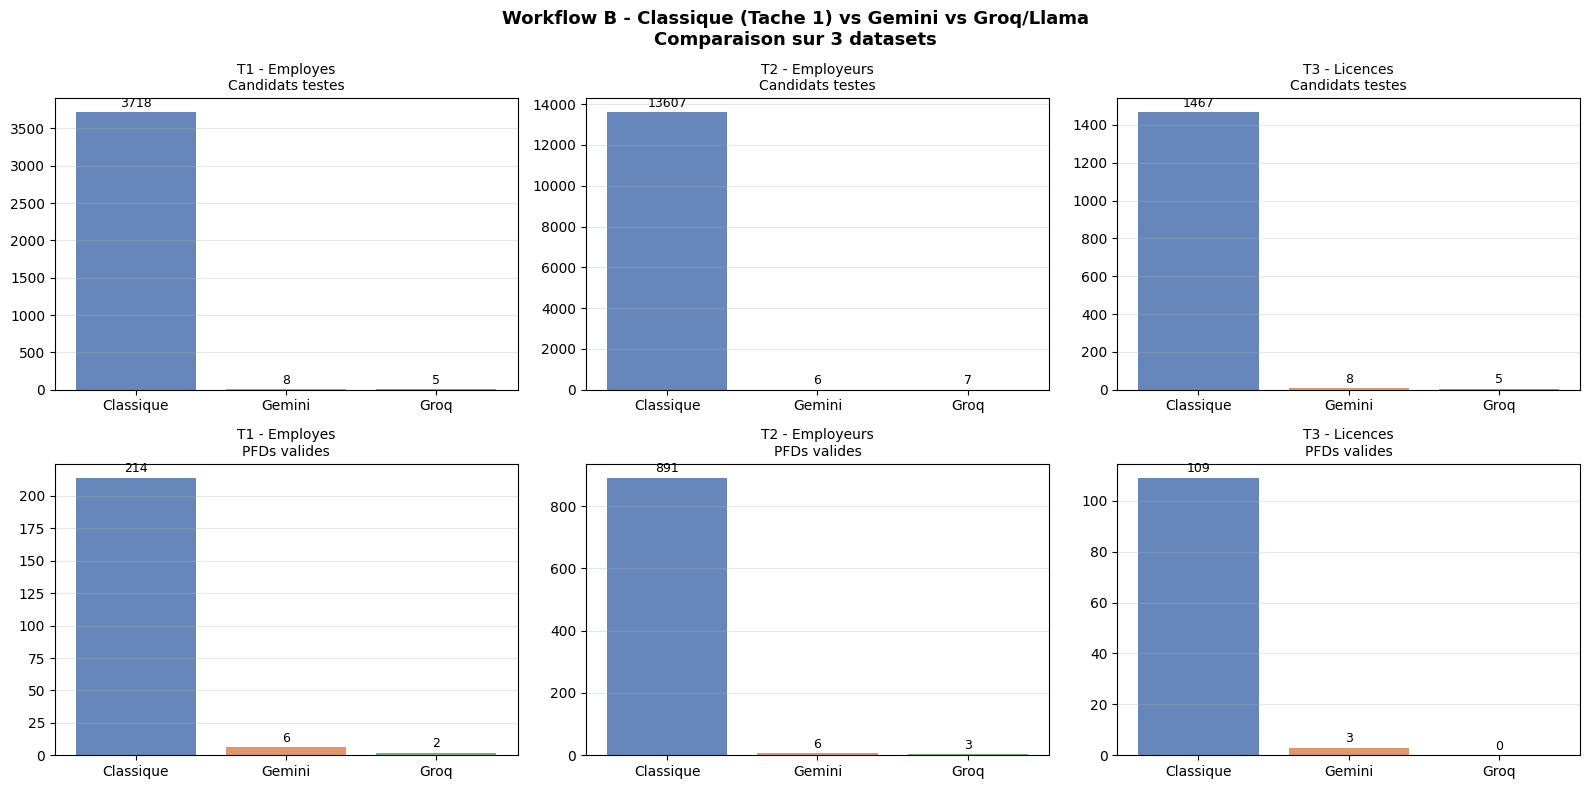

Graphique sauvegarde !


In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Workflow B - Classique (Tache 1) vs Gemini vs Groq/Llama\nComparaison sur 3 datasets',
             fontsize=13, fontweight='bold')

data_plot = [
    ('T1 - Employes',
     n_cls_t1, wb_t1_gemini.candidates_tested, wb_t1_groq.candidates_tested,
     len(cls_t1), len(pfds_t1_gemini), len(pfds_t1_groq)),
    ('T2 - Employeurs',
     n_cls_t2, wb_t2_gemini.candidates_tested, wb_t2_groq.candidates_tested,
     len(cls_t2), len(pfds_t2_gemini), len(pfds_t2_groq)),
    ('T3 - Licences',
     n_cls_t3, wb_t3_gemini.candidates_tested, wb_t3_groq.candidates_tested,
     len(cls_t3), len(pfds_t3_gemini), len(pfds_t3_groq)),
]

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Classique', 'Gemini', 'Groq']

for col, (name, cc, wg, wq, rc, rg, rq) in enumerate(data_plot):
    for row, (vals, title) in enumerate([
        ([cc, wg, wq], 'Candidats testes'),
        ([rc, rg, rq], 'PFDs valides'),
    ]):
        ax = axes[row][col]
        bars = ax.bar(labels, vals, color=colors, alpha=0.85)
        ax.set_title(f'{name}\n{title}', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        m = max(vals) if max(vals) > 0 else 1
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + m * 0.02,
                    str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('workflow_b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegarde !')

## Etape 12 - Export des resultats

In [ ]:
for wb, fname in [
    (wb_t1_gemini, 'results_t1_gemini.csv'),
    (wb_t1_groq,   'results_t1_groq.csv'),
    (wb_t2_gemini, 'results_t2_gemini.csv'),
    (wb_t2_groq,   'results_t2_groq.csv'),
    (wb_t3_gemini, 'results_t3_gemini.csv'),
    (wb_t3_groq,   'results_t3_groq.csv'),
]:
    wb.export_csv(fname)
print('Tous les resultats exportes !')

## Etape 13 - Resume pour le rapport

In [30]:
print('RESUME TACHE 2 - WORKFLOW B GUIDED SEARCH')
print('LLMs : Gemini (Google) vs Groq/Llama-3.3 (Meta)')
print('Algo classique : pipeline complet du camarade (Tache 1)')
print('=' * 65)
for name, wb_g, wb_q, cls, n_cls in [
    ('T1', wb_t1_gemini, wb_t1_groq, cls_t1, n_cls_t1),
    ('T2', wb_t2_gemini, wb_t2_groq, cls_t2, n_cls_t2),
    ('T3', wb_t3_gemini, wb_t3_groq, cls_t3, n_cls_t3),
]:
    red_g = (1 - wb_g.candidates_tested / n_cls) * 100 if n_cls > 0 else 0
    red_q = (1 - wb_q.candidates_tested / n_cls) * 100 if n_cls > 0 else 0
    print(f'\n{name} :')
    print(f'  Classique (Tache 1) : {n_cls} candidats -> {len(cls)} PFDs')
    print(f'  Gemini (Tache 2)    : {wb_g.candidates_tested} candidats -> {len(wb_g.valid_pfds)} PFDs (reduction: {red_g:.0f}%)')
    print(f'  Groq   (Tache 2)    : {wb_q.candidates_tested} candidats -> {len(wb_q.valid_pfds)} PFDs (reduction: {red_q:.0f}%)')

RESUME TACHE 2 - WORKFLOW B GUIDED SEARCH
LLMs : Gemini (Google) vs Groq/Llama-3.3 (Meta)
Algo classique : pipeline complet du camarade (Tache 1)

T1 :
  Classique (Tache 1) : 3718 candidats -> 214 PFDs
  Gemini (Tache 2)    : 8 candidats -> 6 PFDs (reduction: 100%)
  Groq   (Tache 2)    : 5 candidats -> 2 PFDs (reduction: 100%)

T2 :
  Classique (Tache 1) : 13607 candidats -> 891 PFDs
  Gemini (Tache 2)    : 6 candidats -> 6 PFDs (reduction: 100%)
  Groq   (Tache 2)    : 7 candidats -> 3 PFDs (reduction: 100%)

T3 :
  Classique (Tache 1) : 1467 candidats -> 109 PFDs
  Gemini (Tache 2)    : 8 candidats -> 3 PFDs (reduction: 99%)
  Groq   (Tache 2)    : 5 candidats -> 0 PFDs (reduction: 100%)
